# Baseline Random Forest — RAT Classification

Simple Random Forest classifier using only numeric measurement features from a single file.
No time-window aggregation, no neural network, no transfer learning.

In [3]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

sys.path.append("..")
from src.config import path_list, EXCLUDED_COLS, TARGET_COL
from sklearn.metrics import (
                            accuracy_score, 
                            precision_score, 
                            recall_score, 
                            f1_score, 
                            confusion_matrix
                            )
INPUT_FILE = os.path.join(path_list["DATASET_DIR"], "figure5_packet_loss.csv")

RANDOM_STATE = 42
TEST_SIZE = 0.25

### Load data

In [ ]:
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head(3)

### Select measurement features

Exclude metadata columns and constant columns (e.g., `bytes` = 64 everywhere, `target_ip` has 1 unique value).
Only keep numeric columns with variance.

In [5]:
feature_cols = [
    c for c in df.columns if c not in EXCLUDED_COLS and pd.api.types.is_numeric_dtype(df[c])
]
feature_cols = [c for c in feature_cols if df[c].nunique() > 1]
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

Feature columns (3): ['icmp_seq', 'ttl', 'rtt_ms']


In [6]:
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print("Target distribution:")
print(y.value_counts().sort_index())

Target distribution:
rat
0    33204
2     8400
7    21400
8    14121
9    17891
Name: count, dtype: int64


### Train / test split (stratified)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 71,262  |  Test: 23,754


### Train Random Forest

In [8]:
clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

### Evaluation

In [9]:
labels = sorted(y.unique())
label_names = [str(l) for l in labels]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:       {acc:.4f}")
print(f"Precision (w):  {prec:.4f}")
print(f"Recall (w):     {rec:.4f}")
print(f"F1-score (w):   {f1:.4f}")

Accuracy:       0.6960
Precision (w):  0.6897
Recall (w):     0.6960
F1-score (w):   0.6921


### Confusion Matrix

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
cm_df

,0,2,7,8,9
0,5827,722,241,819,692
2,981,795,31,135,158
7,300,14,4591,433,12
8,1169,178,508,1603,72
9,530,160,9,57,3717


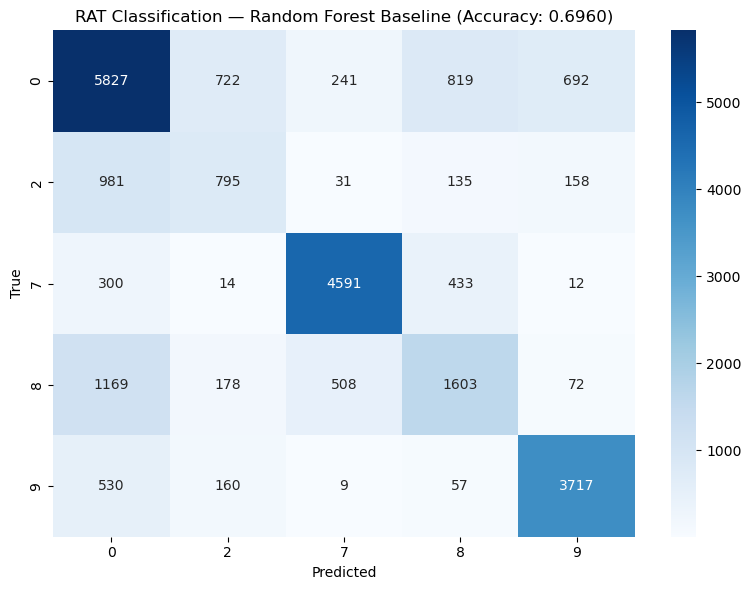

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title(f"RAT Classification — Random Forest Baseline (Accuracy: {acc:.4f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
fig.tight_layout()
plt.show()

### Feature Importance

In [10]:
importance = pd.DataFrame({
    "feature": feature_cols, "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)
importance

,feature,importance
2,rtt_ms,0.777265
0,icmp_seq,0.200194
1,ttl,0.022541


### Notes

- Only 3 measurement features available in this file: `icmp_seq`, `ttl`, `rtt_ms`.
- `rtt_ms` dominates (77% importance) — latency is the strongest single-feature RAT discriminator.
- 3G (class 2) and LTE-M (class 8) are frequently misclassified as 2G (class 0), suggesting overlapping RTT/TTL distributions.
- Next step: incorporate time-window aggregated features and/or combine multiple measurement types.